In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(os.listdir(extract_path))

Unzipped successfully!
['FruitinAmazon']


In [10]:
for root, dirs, files in os.walk("/content/FruitinAmazon"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])
    print("-" * 50)

ROOT: /content/FruitinAmazon
DIRS: ['FruitinAmazon']
FILES: []
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon
DIRS: ['test', 'train']
FILES: []
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test
DIRS: ['pupunha', 'graviola', 'guarana', 'acai', 'tucuma', 'cupuacu']
FILES: []
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test/pupunha
DIRS: []
FILES: ['download (2).jpeg', 'download (3).jpeg', 'download (11).jpeg', 'download (4).jpeg', 'download (1).jpeg']
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test/graviola
DIRS: []
FILES: ['images (4).jpeg', 'download (2).jpeg', 'download (3).jpeg', 'download (4).jpeg', 'download (1).jpeg']
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test/guarana
DIRS: []
FILES: ['images (4).jpeg', 'download (2).jpeg', 'downloa

In [11]:
train_dir = "/content/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/FruitinAmazon/test"

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [12]:
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_image = random.choice(image_files)
    sample_images.append((class_name, os.path.join(class_path, random_image)))

print(sample_images)

[('acai', '/content/FruitinAmazon/FruitinAmazon/train/acai/images (14).jpeg'), ('cupuacu', '/content/FruitinAmazon/FruitinAmazon/train/cupuacu/images (5).jpeg'), ('graviola', '/content/FruitinAmazon/FruitinAmazon/train/graviola/images (2).jpeg'), ('guarana', '/content/FruitinAmazon/FruitinAmazon/train/guarana/download (9).jpeg'), ('pupunha', '/content/FruitinAmazon/FruitinAmazon/train/pupunha/images (2).jpeg'), ('tucuma', '/content/FruitinAmazon/FruitinAmazon/train/tucuma/download.jpeg')]


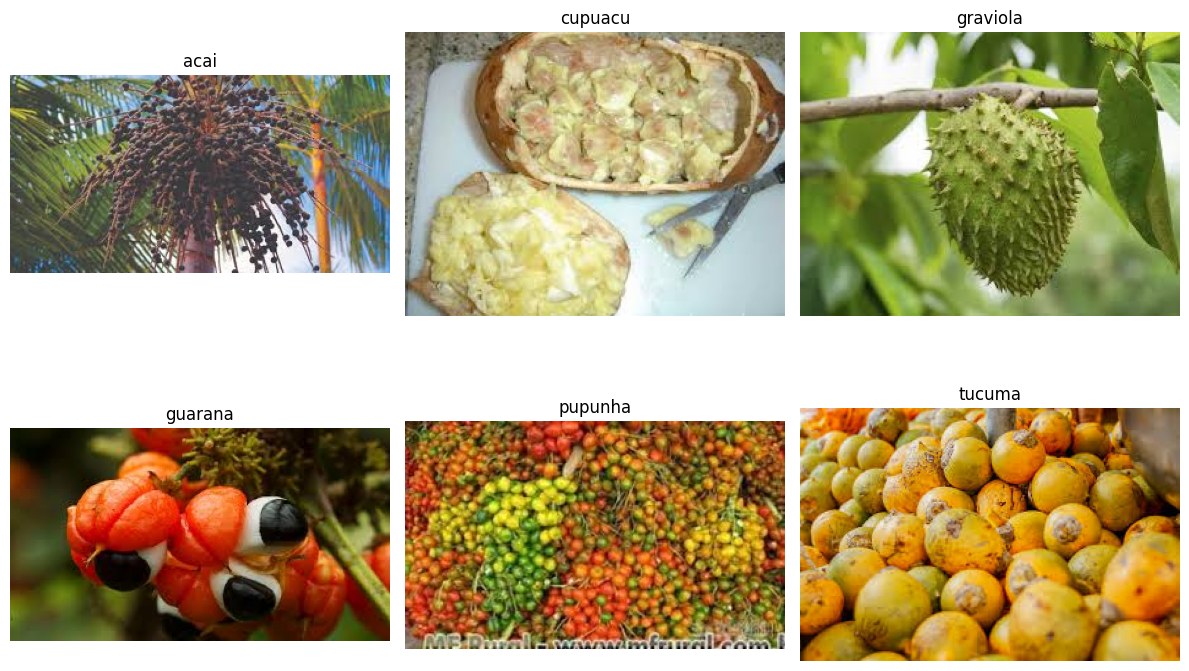

In [13]:
plt.figure(figsize=(12, 8))

rows = 2
cols = 3

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
def remove_corrupted_images(directory):
    corrupted_files = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(file_path)
                os.remove(file_path)
                print("Removed corrupted image:", file_path)

    if not corrupted_files:
        print("No Corrupted Images Found.")

    return corrupted_files

In [15]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [16]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [17]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [18]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [19]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [20]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [21]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [22]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [24]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.2389 - loss: 2.6688
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 456ms/step - accuracy: 0.2361 - loss: 2.6280 - val_accuracy: 0.0000e+00 - val_loss: 1.9192
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2212 - loss: 1.7851
Epoch 2: val_accuracy improved from 0.00000 to 0.72222, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.1944 - loss: 1.7624 - val_accuracy: 0.7222 - val_loss: 1.5265
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3646 - loss: 1.6725
Epoch 3: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.3750 - loss: 1.6239 - val_accuracy: 0.2778 - val_loss: 1.6163
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3545 - loss: 1.5450
Epoch 4: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 349ms/step - accuracy: 0.3611 - loss: 1.4757 - val_accuracy: 0.3889 - val_loss: 1.5182
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.4024 - loss: 1.3891
Epoch 5: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.4028 - loss: 1.3036 - val_accuracy: 0.5556 - val_loss: 1.3320
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.4983 - loss:


Epoch 7: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 573ms/step - accuracy: 0.7639 - loss: 0.8505 - val_accuracy: 0.8333 - val_loss: 0.8276
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8649 - loss: 0.7054
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.9028 - loss: 0.5834 - val_accuracy: 0.8333 - val_loss: 0.6079
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9260 - loss: 0.4752
Epoch 9: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.9583 - loss: 0.3622 - val_accuracy: 0.8333 - val_loss: 0.4190
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9549 - loss: 0.2581
Epoch 10: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.9722 - loss: 0.1968 - val_accuracy: 0.8333 - val_loss: 0.5392
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9510 - lo


Epoch 11: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.9583 - loss: 0.1445 - val_accuracy: 0.8889 - val_loss: 0.5800
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9521 - loss: 0.1484
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.9583 - loss: 0.1295 - val_accuracy: 0.6667 - val_loss: 0.5853
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 1.0000 - loss: 0.1072
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 461ms/step - accuracy: 1.0000 - loss: 0.0836 - val_accuracy: 0.7778 - val_loss: 1.1195
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 1.0000 - loss: 0.1141
Epoch 14: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 603ms/step - accuracy: 1.0000 - loss: 0.0765 - val_accuracy: 0.7778 - val_loss: 0.5525
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9573


Epoch 17: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 347ms/step - accuracy: 0.9722 - loss: 0.1158 - val_accuracy: 0.9444 - val_loss: 0.1483
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 1.0000 - loss: 0.0312
Epoch 18: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 1.0000 - loss: 0.0301 - val_accuracy: 0.8889 - val_loss: 0.5399
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 1.0000 - loss: 0.0314
Epoch 19: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 583ms/step - accuracy: 1.0000 - loss: 0.0305 - val_accuracy: 0.8333 - val_loss: 0.8897
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 1.0000 - loss: 0.0255
Epoch 20: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 1.0000 - loss: 0.0206 - val_accuracy: 0.8333 - val_loss: 0.7559
Epoch 21/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 1.0000

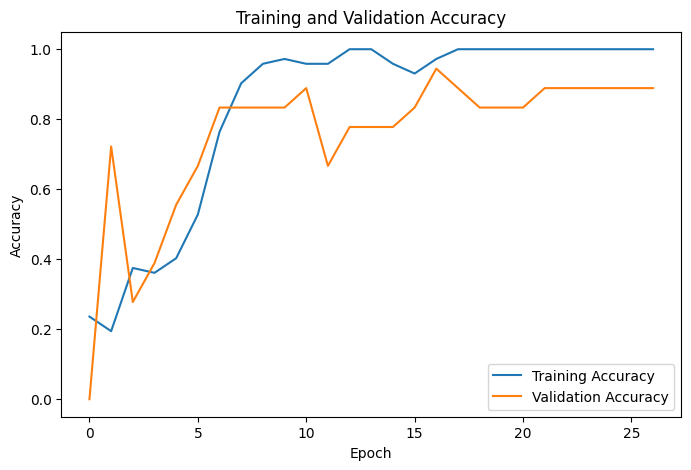

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

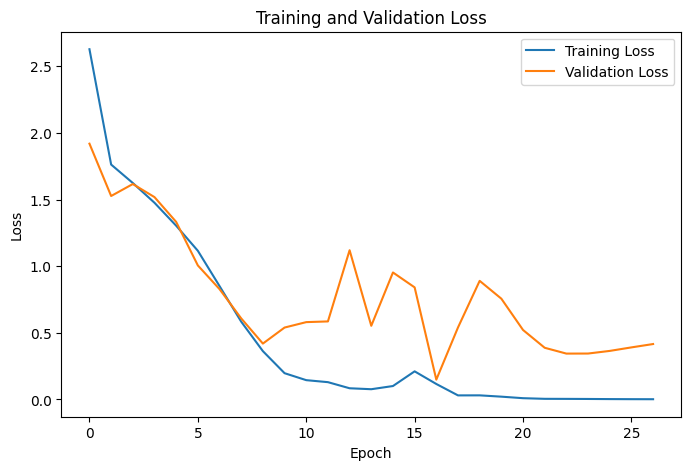

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [31]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7000 - loss: 0.7553
Test Loss: 0.7553218603134155
Test Accuracy: 0.699999988079071


In [32]:
model.save("fruit_classifier_final.h5")
print("Model saved successfully.")

Model saved successfully.


In [33]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
print("Model loaded successfully.")

Model loaded successfully.


In [34]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7000 - loss: 0.7553
Loaded Model Test Loss: 0.7553218603134155
Loaded Model Test Accuracy: 0.699999988079071


In [35]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [36]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.62      1.00      0.77         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.71      1.00      0.83         5
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.70        30
   macro avg       0.68      0.70      0.67        30
weighted avg       0.68      0.70      0.67        30



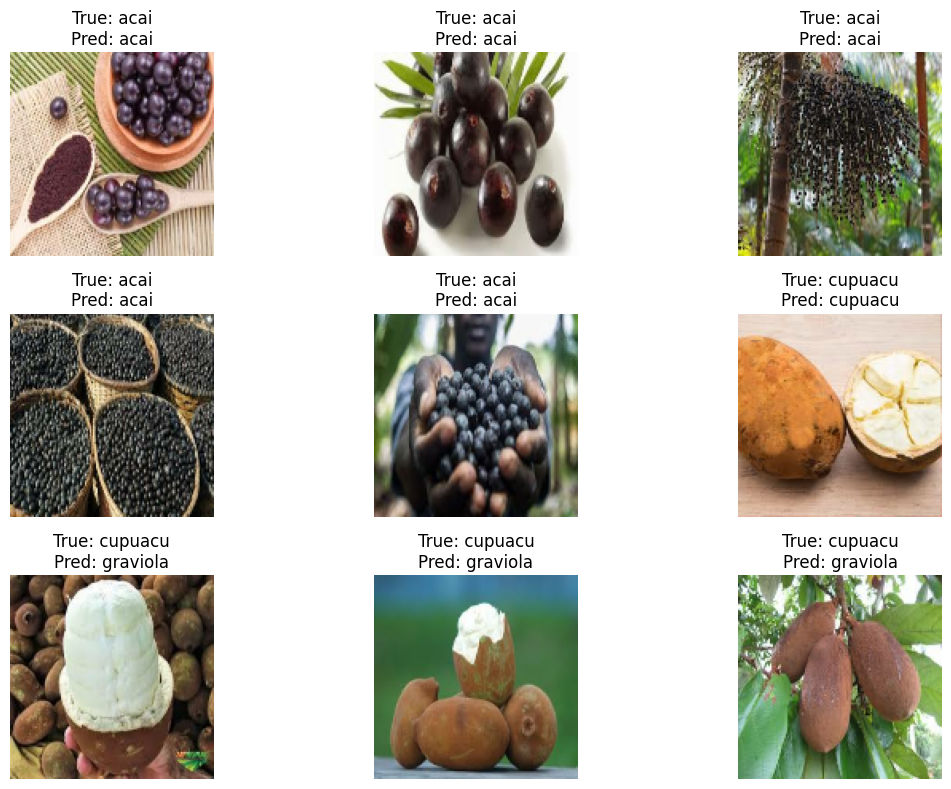

In [37]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
import os

if os.path.exists("fruit_classifier_final.h5"):
    print("Model file exists.")
    print("File name:", "fruit_classifier_final.h5")
    print("File size:", os.path.getsize("fruit_classifier_final.h5"), "bytes")
else:
    print("Model file not found.")

Model file exists.
File name: fruit_classifier_final.h5
File size: 25442992 bytes


In [39]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,456 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)